In [1]:
import numpy as np
import sys
from scipy.signal import detrend
import matplotlib.pyplot as plt
import matplotlib as mpl
sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/")
from EOF import EOF
import h5py 

import statsmodels.tsa.api as smt
from tqdm import tqdm
from scipy.signal import detrend
import statsmodels.tsa.stattools as smt
from tqdm import tqdm

In [2]:
def load_and_preprocess_u(file_path, start_idx=20000, y_start=32):
    """Loads u-component data from HDF5 and computes the time-z-y mean."""
    with h5py.File(file_path, "r") as file:
        print(f"Loading {file_path} - Keys: {list(file.keys())}")
        u_data = np.array(file['u'], dtype=np.float32)
    
    # Extract and calculate mean over axis 3 (longitude)
    u_bar_extract = u_data[start_idx:, :, y_start:, :].mean(axis=3)
    return u_bar_extract

def compute_weighted_eof(u_bar_extract):
    """Calculates vertical mean, applies latitude weights, and performs EOF."""
    u_bar_extract_vertical_mean = u_bar_extract.mean(axis=1)

    # Weigh u before EOF
    lat_regular_extract = np.linspace(0, 90, u_bar_extract.shape[2])
    weights = np.sqrt(np.cos(np.deg2rad(lat_regular_extract)))
    weighted_u = u_bar_extract_vertical_mean * weights

    eof_instance = EOF((weighted_u,), n_components=2, field='1D')
    eof_instance.get()

    EOF1 = eof_instance.EOF[0]
    EOF2 = eof_instance.EOF[1]
    PC1 = eof_instance.PC[0]
    PC2 = eof_instance.PC[1]

    # Normalization
    PC1_normalized = PC1 / PC1.std()
    PC2_normalized = PC2 / PC2.std()
    EOF1_normalized = EOF1 * PC1.std()
    EOF2_normalized = EOF2 * PC1.std()

    return EOF1_normalized, EOF2_normalized, PC1_normalized

def compute_chunked_autocorrelation(pc_data, chunk_days=256, overlap_days=128, steps_per_day=4):
    """Computes the averaged autocorrelation of a Principal Component using overlapping chunks."""
    chunk_steps = chunk_days * steps_per_day        
    overlap_steps = overlap_days * steps_per_day    
    step_size = chunk_steps - overlap_steps  
    max_safe_lags = chunk_steps - 1

    valid_chunks = 0
    auto_z_accum = np.zeros(max_safe_lags)

    for j in range(0, len(pc_data) - chunk_steps + 1, step_size):
        z_chunk = detrend(pc_data[j : j + chunk_steps], type='linear') 
        
        auto_z_chunk = np.zeros(max_safe_lags)
        auto_z_chunk[0] = 1.0

        for k in range(1, max_safe_lags):
            auto_z_chunk[k] = np.corrcoef(z_chunk[k:], z_chunk[:-k])[0, 1] 
            
        auto_z_accum += auto_z_chunk
        valid_chunks += 1

    return auto_z_accum / valid_chunks


In [3]:
file_path = '/data92/PeterChang/Dycore_data/PR0/u/PR0_500_20000day_u_6hourly.h5'
with h5py.File(file_path, "r") as file:
    print(file.keys())
    u_data_0 = np.array(file['u'], dtype=np.float32)
###################################################################################
file_path = '/data92/PeterChang/Dycore_data/PR50/u/PR50_500_20000day_u_6hourly.h5'
with h5py.File(file_path, "r") as file:
    print(file.keys())
    u_data_50 = np.array(file['u'], dtype=np.float32)
###################################################################################
file_path = '/data92/PeterChang/Dycore_data/PR20/u/PR20_500_20000day_u_6hourly.h5'
with h5py.File(file_path, "r") as file:
    print(file.keys())
    u_data_20 = np.array(file['u'], dtype=np.float32)

<KeysViewHDF5 ['u']>
<KeysViewHDF5 ['u']>
<KeysViewHDF5 ['u']>


In [4]:
u_bar_extract_0   = u_data_0[5000 * 4: , : ,32:, :].mean(axis=3)  # (time, z, y)
u_bar_extract_20  = u_data_20[5000 * 4: , : ,32:, :].mean(axis=3) # (time, z, y)
u_bar_extract_50  = u_data_50[5000 * 4: , : ,32:, :].mean(axis=3) # (time, z, y)


In [5]:
EOF1_normalized_0, EOF2_normalized_0, PC1_normalized_0 = compute_weighted_eof(u_bar_extract_0)
EOF1_normalized_20, EOF2_normalized_20, PC1_normalized_20 = compute_weighted_eof(u_bar_extract_20)
EOF1_normalized_50, EOF2_normalized_50, PC1_normalized_50 = compute_weighted_eof(u_bar_extract_50)

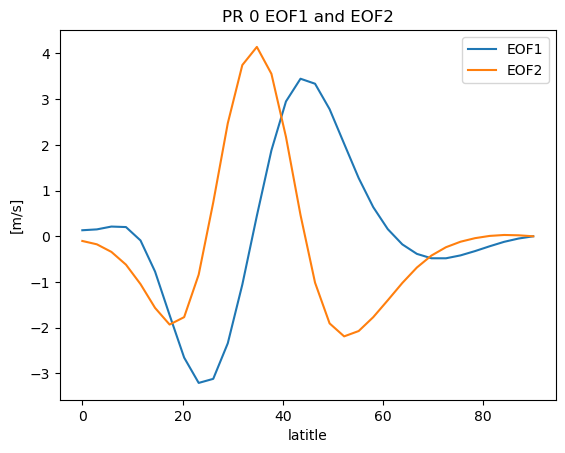

In [6]:
# plot EOF1 and EOF2 to check 
lat_regular_extract = np.linspace(0, 90, 32)
plt.plot(lat_regular_extract, EOF1_normalized_0, label="EOF1")
plt.plot(lat_regular_extract, EOF2_normalized_0, label="EOF2")
plt.xlabel("latitle")
plt.ylabel("[m/s]")
plt.title("PR 0 EOF1 and EOF2")
plt.legend()

In [7]:
steps_per_day = 4
chunk_days    = 256
overlap_days  = 128

chunk_steps   = chunk_days   * steps_per_day        
overlap_steps = overlap_days * steps_per_day    
step_size     = chunk_steps  - overlap_steps  

valid_chunks = 0

max_safe_lags = chunk_steps - 1 # 1023

auto_z_accum_0 = np.zeros(max_safe_lags)
for j in range(0, len(PC1_normalized_0) - chunk_steps + 1, step_size):
    z_chunk = detrend(PC1_normalized_0[j : j + chunk_steps], type='linear') 
    
    auto_z_chunk_0 = np.zeros(max_safe_lags)
    auto_z_chunk_0[0] = 1.0

    for k in range(1, max_safe_lags):
        auto_z_chunk_0[k] = np.corrcoef(z_chunk[k:], z_chunk[:-k])[0, 1] 
        
    auto_z_accum_0 += auto_z_chunk_0
    valid_chunks += 1
###############################################################################
steps_per_day = 4
chunk_days    = 256
overlap_days  = 128

chunk_steps   = chunk_days   * steps_per_day        
overlap_steps = overlap_days * steps_per_day    
step_size     = chunk_steps  - overlap_steps  

valid_chunks = 0

max_safe_lags = chunk_steps - 1 # 1023

auto_z_accum_50 = np.zeros(max_safe_lags)
for j in range(0, len(PC1_normalized_50) - chunk_steps + 1, step_size):
    z_chunk = detrend(PC1_normalized_50[j : j + chunk_steps], type='linear') 
    
    auto_z_chunk_50 = np.zeros(max_safe_lags)
    auto_z_chunk_50[0] = 1.0

    for k in range(1, max_safe_lags):
        auto_z_chunk_50[k] = np.corrcoef(z_chunk[k:], z_chunk[:-k])[0, 1] 
        
    auto_z_accum_50 += auto_z_chunk_50
    valid_chunks += 1
###############################################################################
steps_per_day = 4
chunk_days    = 256
overlap_days  = 128

chunk_steps   = chunk_days   * steps_per_day        
overlap_steps = overlap_days * steps_per_day    
step_size     = chunk_steps  - overlap_steps  

valid_chunks = 0

max_safe_lags = chunk_steps - 1 # 1023

auto_z_accum_20 = np.zeros(max_safe_lags)
for j in range(0, len(PC1_normalized_20) - chunk_steps + 1, step_size):
    z_chunk = detrend(PC1_normalized_20[j : j + chunk_steps], type='linear') 
    
    auto_z_chunk_20 = np.zeros(max_safe_lags)
    auto_z_chunk_20[0] = 1.0

    for k in range(1, max_safe_lags):
        auto_z_chunk_20[k] = np.corrcoef(z_chunk[k:], z_chunk[:-k])[0, 1] 
        
    auto_z_accum_20 += auto_z_chunk_20
    valid_chunks += 1


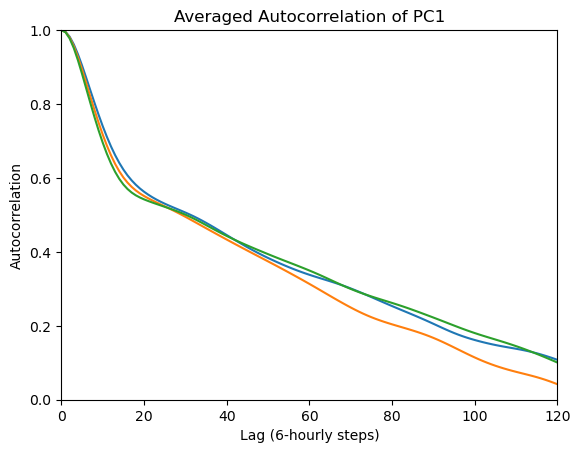

In [8]:
auto_z_avg_0   = auto_z_accum_0 / valid_chunks
auto_z_avg_20  = auto_z_accum_20 / valid_chunks
auto_z_avg_50  = auto_z_accum_50 / valid_chunks


# Plot the corrected, averaged result
plt.plot(auto_z_avg_0)
plt.plot(auto_z_avg_20)
plt.plot(auto_z_avg_50)

plt.xlim([0, 30 * steps_per_day]) # 30 day
plt.ylim([0, 1])
plt.xlabel('Lag (6-hourly steps)')
plt.ylabel('Autocorrelation')
plt.title('Averaged Autocorrelation of PC1')
plt.show()

# $dlog(C_{z1z1}) \over d\tau$

In [9]:
length = auto_z_avg_0.shape[0]
result_0 = np.zeros(length)
result_20 = np.zeros(length)
result_50 = np.zeros(length)

for i in range(1, length):
    result_0[i]  = np.log(auto_z_avg_0[i]) / i
    result_20[i]  = np.log(auto_z_avg_20[i]) / i
    
    result_50[i] = np.log(auto_z_avg_50[i]) / i
    

/tmp/ipykernel_992541/2933540036.py:8: RuntimeWarning: invalid value encountered in log
  result_20[i]  = np.log(auto_z_avg_20[i]) / i
/tmp/ipykernel_992541/2933540036.py:10: RuntimeWarning: invalid value encountered in log
  result_50[i] = np.log(auto_z_avg_50[i]) / i
/tmp/ipykernel_992541/2933540036.py:7: RuntimeWarning: invalid value encountered in log
  result_0[i]  = np.log(auto_z_avg_0[i]) / i


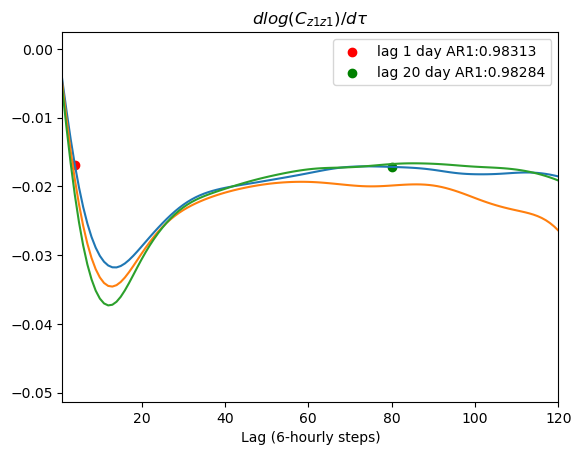

In [10]:
plt.plot(result_0)
plt.plot(result_20)

plt.plot(result_50)

plt.xlim([1,30*4])
plt.scatter(4, result_0[4], color="Red", label="lag 1 day AR1:" +str(round(1 + result_0[4],5)))
plt.scatter(4*20, result_0[4 * 20], color="Green", label="lag 20 day AR1:" +str(round(1 + result_0[4 * 20],5)))
plt.title(r"$dlog(C_{z1z1}) / d\tau$")
plt.xlabel('Lag (6-hourly steps)')
plt.legend()

In [11]:
def autocorrelation_AR(PC1, do_detrend, do_chunk, chunk_days, AR):
    if do_chunk:
        steps_per_day = 4
        overlap_days  = int(chunk_days // 2) # 128
        
        chunk_steps   = chunk_days   * steps_per_day        
        overlap_steps = overlap_days * steps_per_day    
        step_size     = chunk_steps  - overlap_steps  
        
        valid_chunks = 0
        
        max_safe_lags = chunk_steps - 1 # 1023
        
        auto_z_accum = np.zeros(max_safe_lags)
        if do_detrend:
            for j in range(0, len(PC1) - chunk_steps + 1, step_size):
                z_chunk = detrend(PC1[j : j + chunk_steps], type='linear') 
                
                auto_z_chunk = np.zeros(max_safe_lags)
                auto_z_chunk[0] = 1.0
            
                for k in range(1, max_safe_lags):
                    auto_z_chunk[k] = np.corrcoef(z_chunk[k:], z_chunk[:-k])[0, 1] 
                    
                auto_z_accum += auto_z_chunk
                valid_chunks += 1
        else:
            for j in range(0, len(PC1) - chunk_steps + 1, step_size):
                z_chunk = PC1[j : j + chunk_steps]
                
                auto_z_chunk = np.zeros(max_safe_lags)
                auto_z_chunk[0] = 1.0
            
                for k in range(1, max_safe_lags):
                    auto_z_chunk[k] = np.corrcoef(z_chunk[k:], z_chunk[:-k])[0, 1] 
                    
                auto_z_accum += auto_z_chunk
                valid_chunks += 1
        auto_z_avg = auto_z_accum / valid_chunks
        return auto_z_avg[AR]

    else:
        max_safe_lags = 1024 -1 
        auto_z = np.zeros(max_safe_lags)
        auto_z_accum = np.zeros(max_safe_lags)

        for k in range(1, max_safe_lags):
            auto_z[k] = np.corrcoef(PC1[k:], PC1[:-k])[0, 1] 
        return auto_z[AR]

In [12]:
def logC_over_dtau(auto):
    length = auto.shape[0]
    result = np.zeros(length)
    for i in range(1, length):
        result[i] = np.log(auto[i]) / i
    # AR1 = auto[4 * 5] ** (1/5) # 1 + result[4 * 5]
    # print("AR1:", AR1)
    return result#, AR1      

In [13]:
def plot_auto(auto, length_day, six_hourly_data=True):
    if six_hourly_data:
        fig, ax = plt.subplots(1, figsize=(4,3), dpi=150.)
        ax.plot(auto)
        ax.set_xlim([0,30 * 4])
        ax.set_ylim([-0.05, 1.05])
        ax.set_xlabel('Lag (6-hourly steps)', fontsize=8)
        ax.axhline(y=0, color="Black", lw=0.8)
        ax.set_title("Autocorrelation of PC1 of u", fontsize=12)

In [14]:
def plot_log_auto(dlog_dtau, length_day, six_hourly_data=True):
    if six_hourly_data:
        fig, ax = plt.subplots(1, figsize=(4,3), dpi=150.)
        ax.plot(dlog_dtau)
        ax.set_xlim([0,30 * 4])
        # ax.set_ylim([-0.05, 1.05])
        ax.set_xlabel('Lag (6-hourly steps)', fontsize=8)
        ax.set_title(r"$dlog(C_{z1z1}) /  d\tau$", fontsize=12)



In [15]:
# ==========================================
# 1. 簡化版的函數：只負責切 Chunk 與算 ACF
# ==========================================
def get_bootstrapped_autocorr(data_array, chunk_days, target_lag_days, n_bootstraps=500):
    steps_per_day = 4
    chunk_steps = int(chunk_days * steps_per_day)
    
    # Calculate the exact index we want to extract
    target_lag_steps = int(target_lag_days * steps_per_day)
    
    # 防呆機制：如果 lag 比 chunk 還大，直接回傳 NaN，避免報錯中斷迴圈
    if chunk_steps <= target_lag_steps:
        return np.nan, np.nan, np.nan

    # 優化 Overlap 計算方式
    overlap_steps = chunk_steps // 2 
    step_size = chunk_steps - overlap_steps
    
    chunk_target_lags = []
    
    # 迴圈切 Chunk (直接對傳進來的 data_array 做處理，不再做任何濾波)
    for j in range(0, len(data_array) - chunk_steps + 1, step_size):
        z_chunk = data_array[j : j + chunk_steps]
            
        # Fast ACF calculation
        acf = smt.acf(z_chunk, nlags=target_lag_steps, fft=True)
        
        # Extract ONLY the specific index
        chunk_target_lags.append(acf[target_lag_steps])
        
    chunk_target_lags = np.array(chunk_target_lags)
    n_chunks = len(chunk_target_lags)
    
    if n_chunks == 0:
        return np.nan, np.nan, np.nan
    
    # Vectorized Block Bootstrapping
    boot_samples = np.random.choice(chunk_target_lags, size=(n_bootstraps, n_chunks), replace=True)
    bootstrapped_means = np.mean(boot_samples, axis=1)
        
    mean_val = np.mean(bootstrapped_means)
    p5, p95 = np.percentile(bootstrapped_means, [5, 95])
    
    return mean_val, p5, p95



In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq, irfft

def fft_highpass_filter(data, cutoff_days, steps_per_day=4):
    """
    Performs an FFT-based high-pass filter by isolating the low-frequency
    trend and subtracting it from the original signal.
    """
    N = len(data)
    
    # 1. Perform the FFT (Real FFT, since our time series is real numbers)
    # This gives us the amplitude and phase of every frequency in the data
    fft_coeffs = rfft(data)
    
    # Calculate the exact frequencies (in cycles per day) for each coefficient
    # d = 1 / steps_per_day is the time between samples (0.25 days)
    freqs = rfftfreq(N, d=(1 / steps_per_day))
    
    # 2. Isolate the Low-Pass Signal (periods > 250 days)
    # A period of 250 days means a frequency of 1/250 cycles per day.
    cutoff_freq = 1 / cutoff_days
    
    # Create a copy of the coefficients to modify
    fft_coeffs_lowpass = fft_coeffs.copy()
    
    # Zero out all frequencies HIGHER than our cutoff. 
    # This leaves ONLY the ultra-slow 250-day trend.
    fft_coeffs_lowpass[freqs > cutoff_freq] = 0
    
    # 3. Perform the Inverse FFT to turn it back into a time-series
    # We pass n=N to ensure the output length matches exactly
    low_pass_trend = irfft(fft_coeffs_lowpass, n=N)
    
    # 4. Subtract the trend from the original to get the high-pass signal
    high_pass_signal = data - low_pass_trend
    
    return low_pass_trend, high_pass_signal



In [17]:
# ==========================================
# 2. 主程式：先做 Global FFT，再跑迴圈
# ==========================================
max_days = 500 
n_boot = 500
target_lags = [1, 5, 10, 15, 30]
cutoff_days = 200
steps_per_day = 4

datasets_raw = {
    'PR 0': PC1_normalized_0,
    'PR 20': PC1_normalized_20,
    'PR 50': PC1_normalized_50
}

# 預先處理：對所有資料做 Global 200-day High-pass filter
print("Pre-processing: Applying Global FFT High-pass filter...")
datasets_processed = {}

for name, raw_data in datasets_raw.items():
    # 假設你的 fft_highpass_filter 函數已經定義好
    _, highpass_data = fft_highpass_filter(
        raw_data, 
        cutoff_days=cutoff_days, 
        steps_per_day=steps_per_day
    )
    
    # 將未濾波 (raw) 與已濾波 (highpass) 的陣列包裝在一起
    datasets_processed[name] = {
        'raw': raw_data,
        'highpass': highpass_data
    }

# Master dictionary to store all results
results_dict = {}

print("Running Bootstrap Sensitivity Analysis & Storing Data...")

for lag in target_lags:
    start_day = lag + 1 
    x_axis = np.arange(start_day, max_days)
    
    results_dict[lag] = {}
    
    # 這裡改成對 datasets_processed 取值
    for name, data_dict in datasets_processed.items():
        
        no_dt_means, no_dt_p5s, no_dt_p95s = [], [], []
        dt_means, dt_p5s, dt_p95s = [], [], []

        for i in tqdm(range(start_day, max_days), desc=f"Calculating {name} AR-{lag}"):
            
            # 1. Non-Detrended: 直接餵入 pre-processed 的 raw 資料
            m_no_dt, p5_no_dt, p95_no_dt = get_bootstrapped_autocorr(
                data_dict['raw'], chunk_days=i, target_lag_days=lag, n_bootstraps=n_boot
            )
            no_dt_means.append(m_no_dt)
            no_dt_p5s.append(p5_no_dt)
            no_dt_p95s.append(p95_no_dt)
            
            # 2. Detrended: 直接餵入預先算好的 highpass 資料
            m_dt, p5_dt, p95_dt = get_bootstrapped_autocorr(
                data_dict['highpass'], chunk_days=i, target_lag_days=lag, n_bootstraps=n_boot
            )
            dt_means.append(m_dt)
            dt_p5s.append(p5_dt)
            dt_p95s.append(p95_dt)

        # Store all arrays into the master dictionary
        results_dict[lag][name] = {
            'x_axis': x_axis,
            'no_dt': {'mean': no_dt_means, 'p5': no_dt_p5s, 'p95': no_dt_p95s},
            'dt': {'mean': dt_means, 'p5': dt_p5s, 'p95': dt_p95s}
        }

print("All calculations complete and stored in `results_dict`!")

Pre-processing: Applying Global FFT High-pass filter...
Running Bootstrap Sensitivity Analysis & Storing Data...


Calculating PR 50 AR-30: 100%|████████████████| 469/469 [00:07<00:00, 62.50it/s]

All calculations complete and stored in `results_dict`!


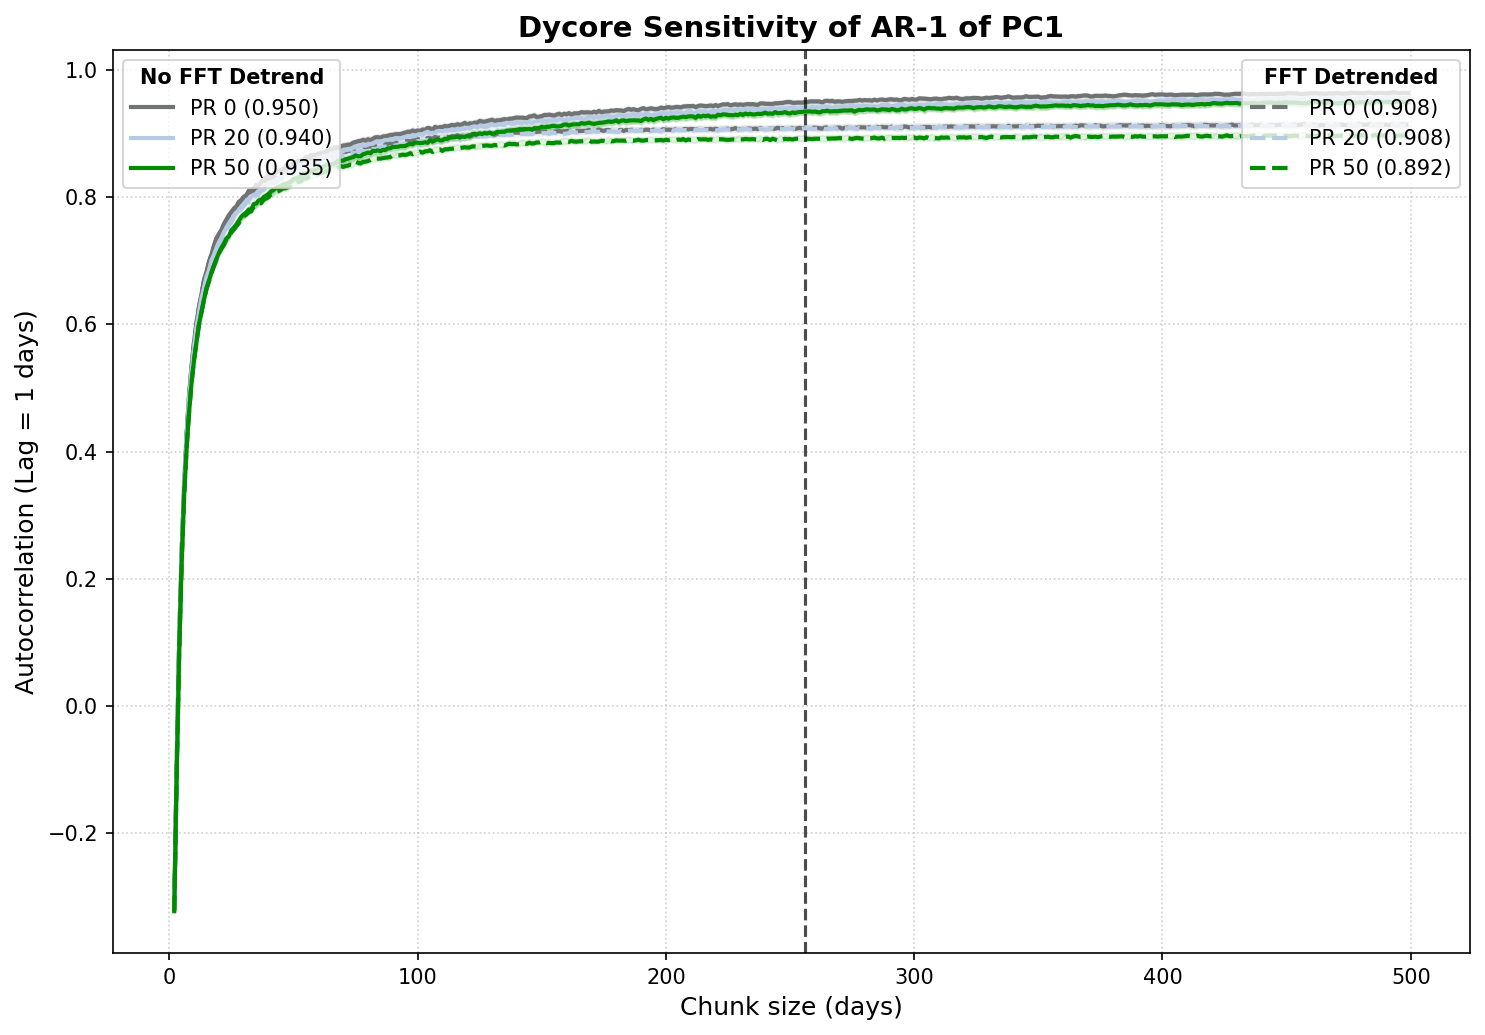

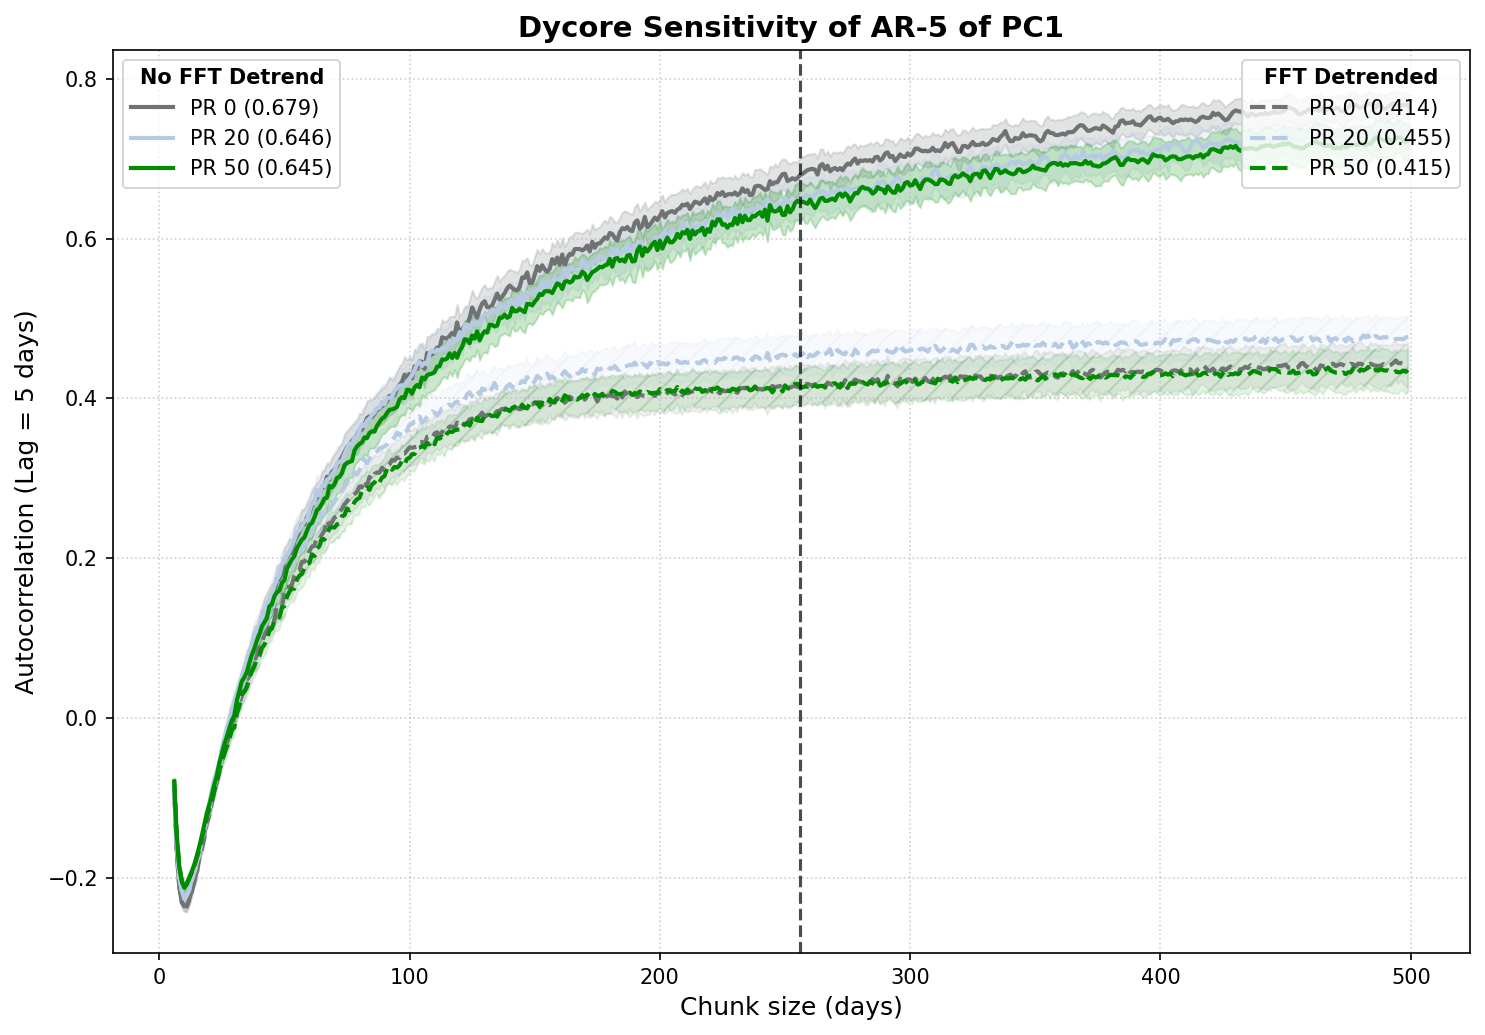

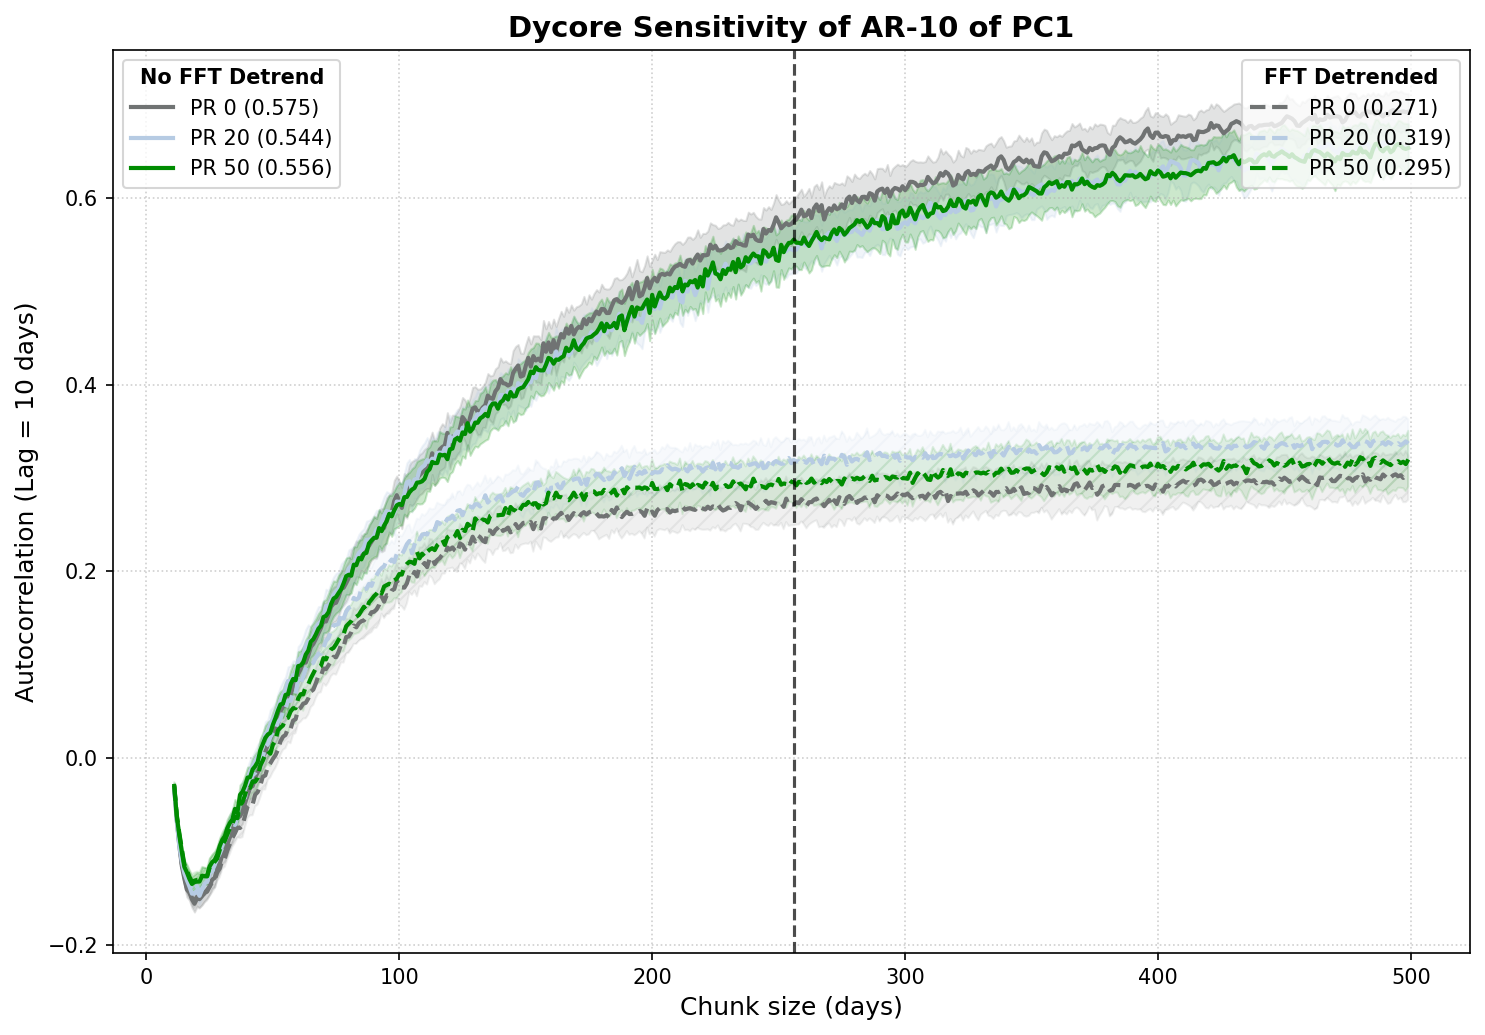

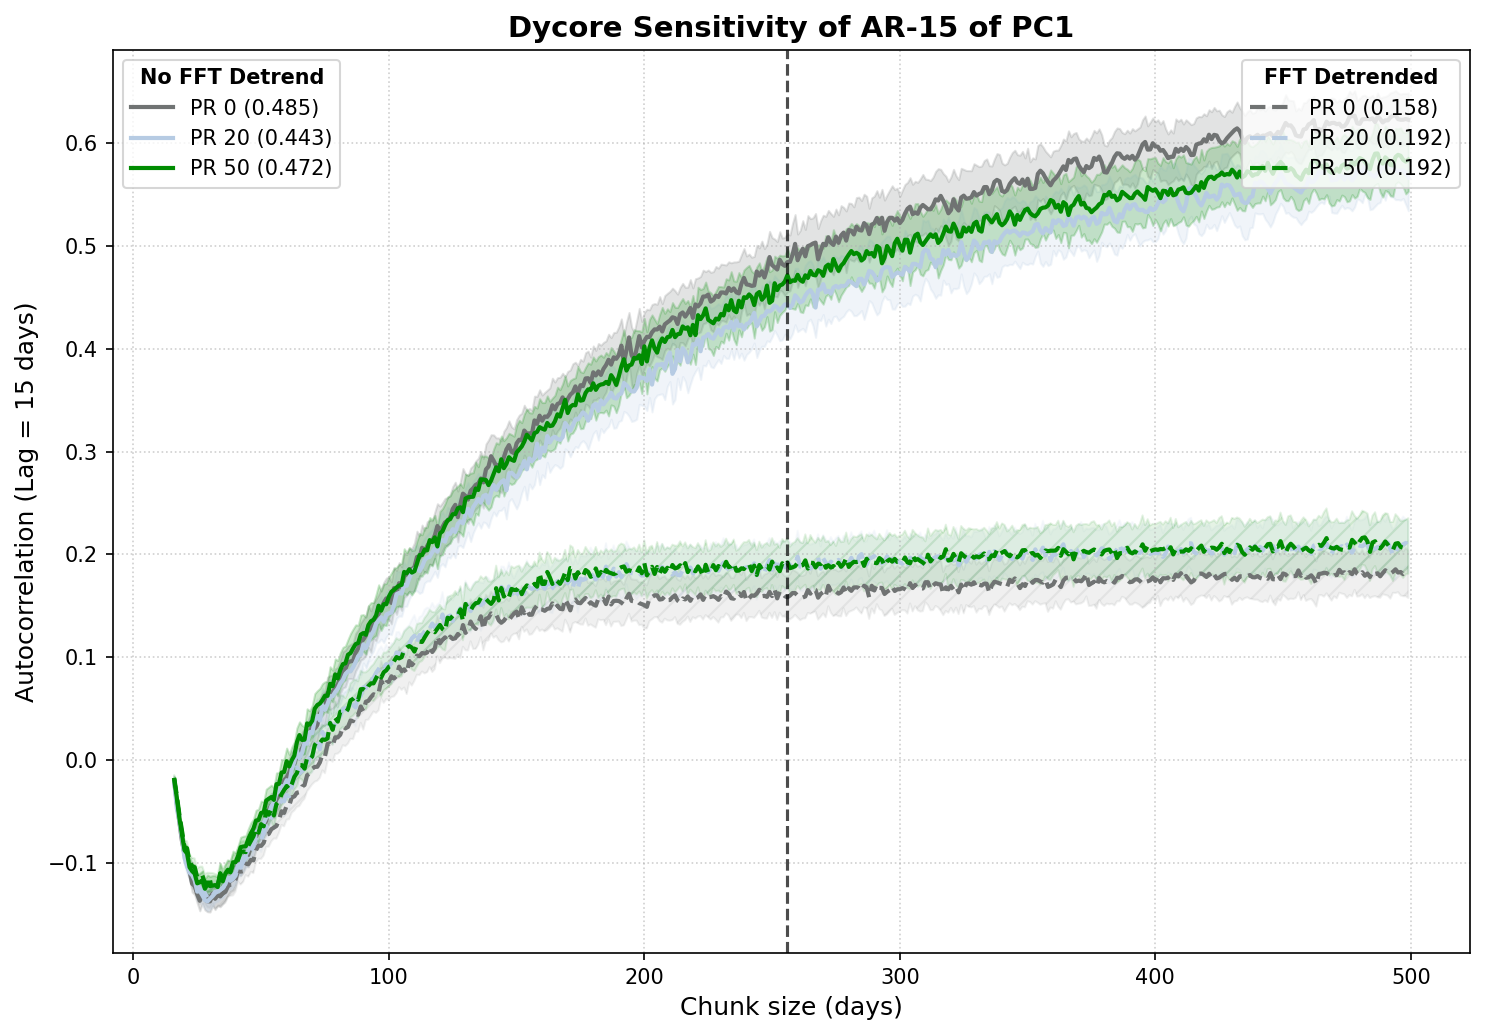

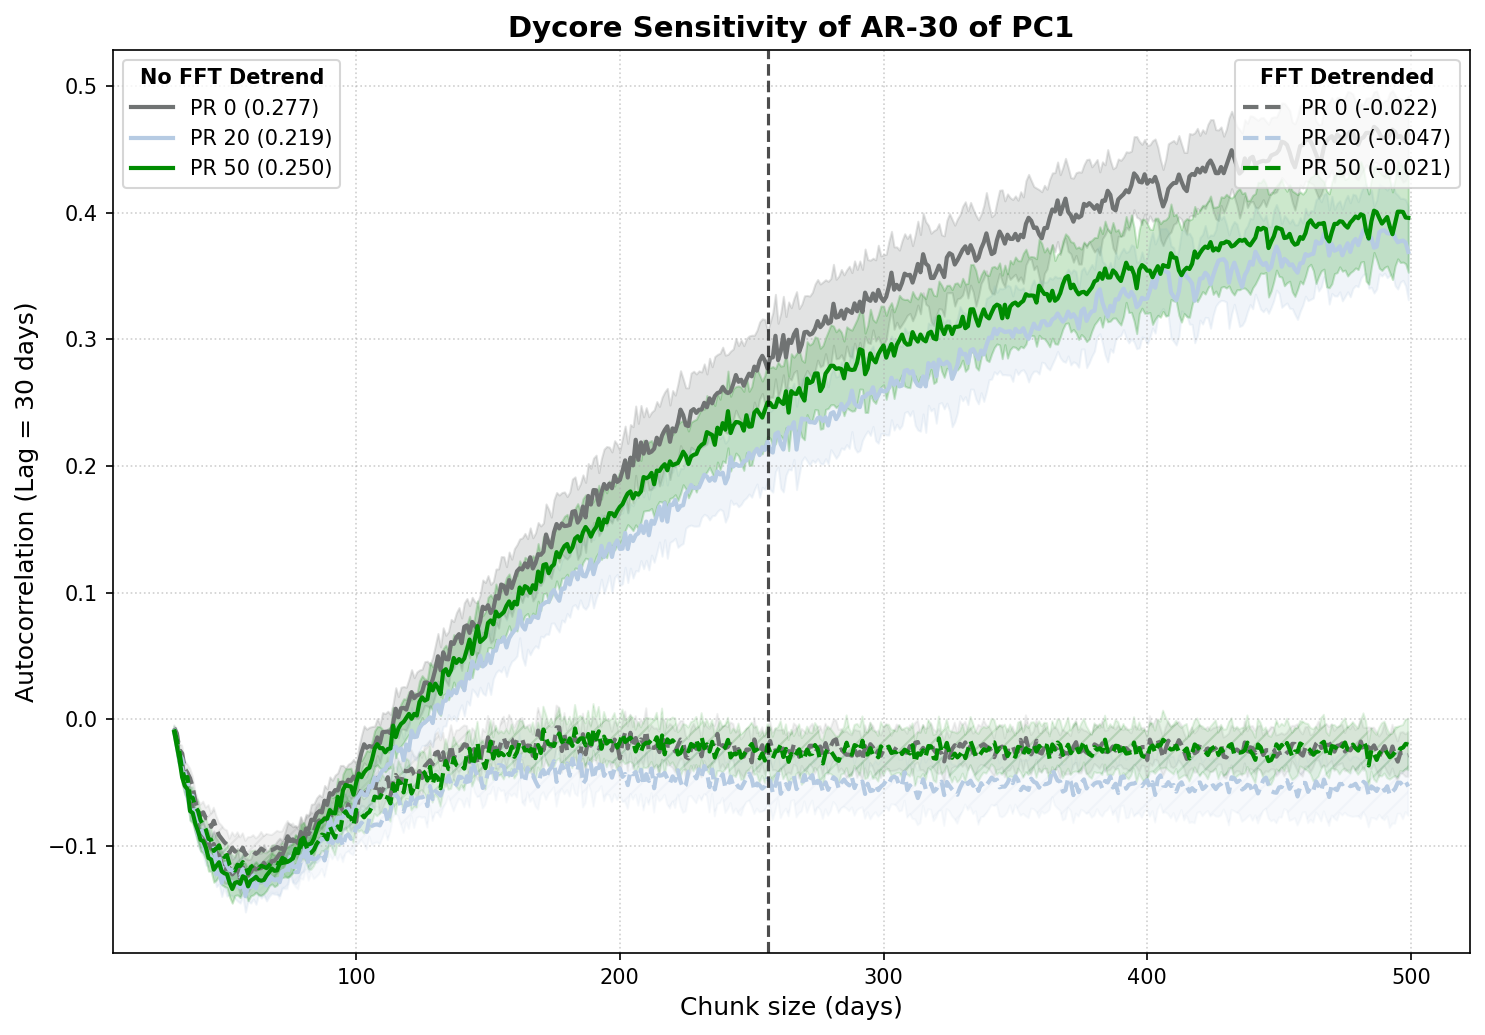

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Assign consistent colors for each experiment
# 1. 定義自訂顏色矩陣 (RGB 轉換為 0~1 之間的數值)
custom_colors = np.array([[112, 115, 115], [182, 203, 227], [0, 140, 1]]) / 255.0

# 2. 將自訂顏色對應到你的實驗組別
colors = {
    'PR 0': custom_colors[0],  # 灰色系
    'PR 20': custom_colors[1], # 淺藍色系
    'PR 50': custom_colors[2]  # 綠色系
}

for lag in target_lags:
    fig, ax = plt.subplots(figsize=(10, 7), dpi=150)
    
    # 建立兩個空的 list 來儲存繪圖物件，以便稍後分開做 Legend
    lines_no_dt = []
    lines_dt = []
    
    for name in datasets_processed.keys():
        # Retrieve the stored data
        data_stored = results_dict[lag][name]
        x_axis = np.array(data_stored['x_axis']) 
        c = colors[name]
        
        # 尋找 x_axis 中最接近 256 的 index 與對應的 Y 值
        idx_256 = np.argmin(np.abs(x_axis - 256))
        val_no_dt = data_stored['no_dt']['mean'][idx_256]
        val_dt = data_stored['dt']['mean'][idx_256]
        
        # --- 1. Plot Non-Detrended (Solid Lines) ---
        line1, = ax.plot(x_axis, data_stored['no_dt']['mean'], 
                         label=f"{name} ({val_no_dt:.3f})", color=c, linestyle='-', linewidth=2)
        lines_no_dt.append(line1) # 存入第一個 legend 的群組
        
        ax.fill_between(x_axis, data_stored['no_dt']['p5'], data_stored['no_dt']['p95'], 
                         color=c, alpha=0.2)
        
        # 在 256 線的右側標示數值 (正體)
        # ax.text(265, val_no_dt, f"{val_no_dt:.3f}", color=c, fontweight='bold', 
                 # va='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
        
        # --- 2. Plot Detrended (Dashed Lines) ---
        line2, = ax.plot(x_axis, data_stored['dt']['mean'], 
                         label=f"{name} ({val_dt:.3f})", color=c, linestyle='--', linewidth=2)
        lines_dt.append(line2) # 存入第二個 legend 的群組
        
        ax.fill_between(x_axis, data_stored['dt']['p5'], data_stored['dt']['p95'], 
                         color=c, alpha=0.1, hatch='//')
        
        # 在 256 線的右側標示數值 (設定 style='italic' 區別虛線的值)
        # ax.text(265, val_dt, f"{val_dt:.3f}", color=c, fontweight='bold', style='italic',
                 # va='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    # --- Formatting the plot ---
    ax.set_xlabel("Chunk size (days)", fontsize=12)
    ax.set_ylabel(f"Autocorrelation (Lag = {lag} days)", fontsize=12)
    ax.set_title(f"Dycore Sensitivity of AR-{lag} of PC1", fontsize=14, fontweight='bold')
    
    # 畫出 256 天的基準線
    ax.axvline(x=256, color="black", linestyle='--', alpha=0.7) 
    # ax.text(256, ax.get_ylim()[0], " chunk=256d", color="black", ha='right', va='bottom', rotation=90)
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # ==========================================
    # 核心技巧：將 Legend 分成兩塊
    # ==========================================
    # 1. 建立第一個 Legend (No Detrend)，放在左上角
    leg1 = ax.legend(handles=lines_no_dt, loc="upper left", title="No FFT Detrend", fontsize=10)
    leg1.get_title().set_fontweight('bold')
    
    # 將 leg1 加入到圖層中 (這樣畫第二個 Legend 時，第一個才不會消失)
    ax.add_artist(leg1) 
    
    # 2. 建立第二個 Legend (Detrended)，放在右上角
    leg2 = ax.legend(handles=lines_dt, loc="upper right", title="FFT Detrended", fontsize=10)
    leg2.get_title().set_fontweight('bold')
    
    plt.tight_layout()
    plt.show()

# 256-day chunk and 128-day overlap autocorrelation to check the Sensitivity correct or not 

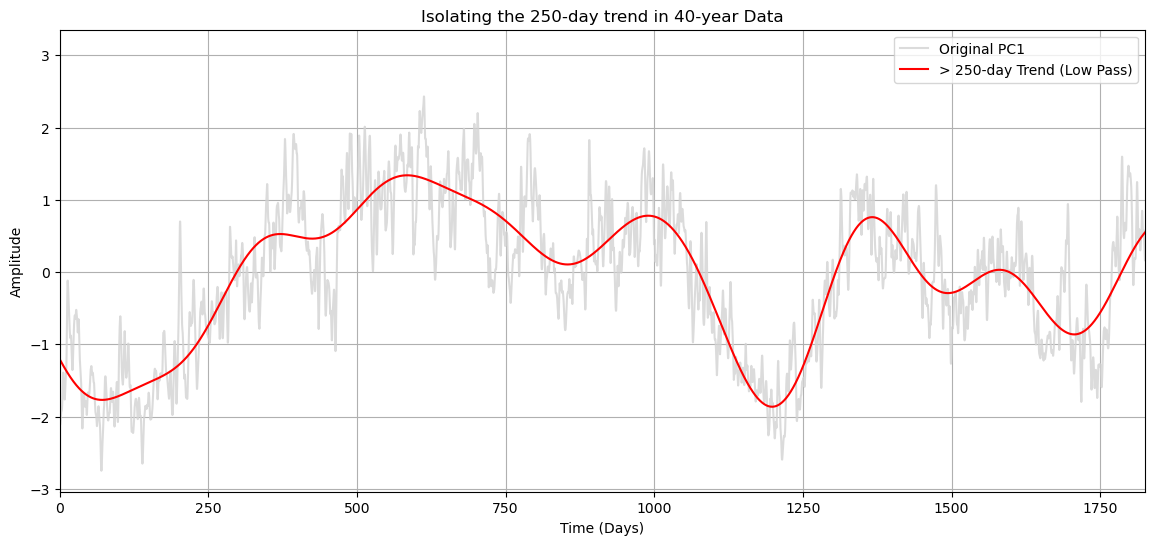

In [19]:
# 1. Apply the FFT filter to your actual data
steps_per_day = 4
cutoff_days = 200

low_pass_trend_0, PC1_highpass_0 = fft_highpass_filter(
    PC1_normalized_0, 
    cutoff_days=cutoff_days, 
    steps_per_day=steps_per_day
)

low_pass_trend_20, PC1_highpass_20 = fft_highpass_filter(
    PC1_normalized_20, 
    cutoff_days=cutoff_days, 
    steps_per_day=steps_per_day
)

low_pass_trend_50, PC1_highpass_50 = fft_highpass_filter(
    PC1_normalized_50, 
    cutoff_days=cutoff_days, 
    steps_per_day=steps_per_day
)

# 2. Create the correct time axis for your 58,000 points
# This will create an array going from 0 to 14,500 days
t_days = np.linspace(0, len(PC1_normalized_0) / steps_per_day, len(PC1_normalized_0), endpoint=False)

# 3. Plotting advice for large datasets
plt.figure(figsize=(14, 6))

# Plotting 58,000 points can look like a solid block of ink. 
# It helps to set an 'alpha' (transparency) or zoom in on a specific window (e.g., the first 5 years)
plt.plot(t_days, PC1_normalized_0, label='Original PC1', color='lightgray', alpha=0.8)
plt.plot(t_days, low_pass_trend_0, label='> 250-day Trend (Low Pass)', color='red', linewidth=1.5)
# plt.plot(t_days, PC1_highpass_0, label='< 250-day Trend (high Pass)', color='green', linewidth=1.5)

plt.title("Isolating the 250-day trend in 40-year Data")
plt.xlabel("Time (Days)")
plt.ylabel("Amplitude")
plt.xlim(0, 1825) # Optional: Zoom in on the first 5 years (5 * 365 = 1825 days) to actually see the waves
plt.legend()
plt.grid(True)
plt.show()

In [20]:
PC1_highpass_0.shape

(58000,)

In [21]:
steps_per_day = 4
chunk_days    = 256
overlap_days  = 128

chunk_steps   = chunk_days   * steps_per_day        
overlap_steps = overlap_days * steps_per_day    
step_size     = chunk_steps  - overlap_steps  

valid_chunks = 0

max_safe_lags = chunk_steps - 1 # 1023

auto_z_accum_0 = np.zeros(max_safe_lags)
for j in range(0, len(PC1_highpass_0) - chunk_steps + 1, step_size):
    # z_chunk = detrend(PC1_normalized_0_filtered[j : j + chunk_steps], type='linear') 
    z_chunk = PC1_highpass_0[j : j + chunk_steps]
    
    
    auto_z_chunk_0 = np.zeros(max_safe_lags)
    auto_z_chunk_0[0] = 1.0

    for k in range(1, max_safe_lags):
        auto_z_chunk_0[k] = np.corrcoef(z_chunk[k:], z_chunk[:-k])[0, 1] 
        
    auto_z_accum_0 += auto_z_chunk_0
    valid_chunks += 1


In [22]:
auto_z_accum_20 = np.zeros(max_safe_lags)
valid_chunks = 0

for j in range(0, len(PC1_highpass_20) - chunk_steps + 1, step_size):
    # z_chunk = detrend(PC1_normalized_0_filtered[j : j + chunk_steps], type='linear') 
    z_chunk = PC1_highpass_20[j : j + chunk_steps]
    
    
    auto_z_chunk_20 = np.zeros(max_safe_lags)
    auto_z_chunk_20[0] = 1.0

    for k in range(1, max_safe_lags):
        auto_z_chunk_20[k] = np.corrcoef(z_chunk[k:], z_chunk[:-k])[0, 1] 
        
    auto_z_accum_20 += auto_z_chunk_20
    valid_chunks += 1

In [23]:
auto_z_accum_50 = np.zeros(max_safe_lags)
valid_chunks = 0

for j in range(0, len(PC1_highpass_50) - chunk_steps + 1, step_size):
    # z_chunk = detrend(PC1_normalized_0_filtered[j : j + chunk_steps], type='linear') 
    z_chunk = PC1_highpass_50[j : j + chunk_steps]
    
    
    auto_z_chunk_50 = np.zeros(max_safe_lags)
    auto_z_chunk_50[0] = 1.0

    for k in range(1, max_safe_lags):
        auto_z_chunk_50[k] = np.corrcoef(z_chunk[k:], z_chunk[:-k])[0, 1] 
        
    auto_z_accum_50 += auto_z_chunk_50
    valid_chunks += 1

In [24]:
auto_z_avg_0_filter   = auto_z_accum_0 / valid_chunks
auto_z_avg_20_filter  = auto_z_accum_20 / valid_chunks
auto_z_avg_50_filter  = auto_z_accum_50 / valid_chunks



In [25]:
colors = np.array([[112, 115, 115], [182, 203, 227], [89, 159, 218], 
                   [0, 83, 170], [0, 4, 167], [0, 140, 1]]) / 255.0

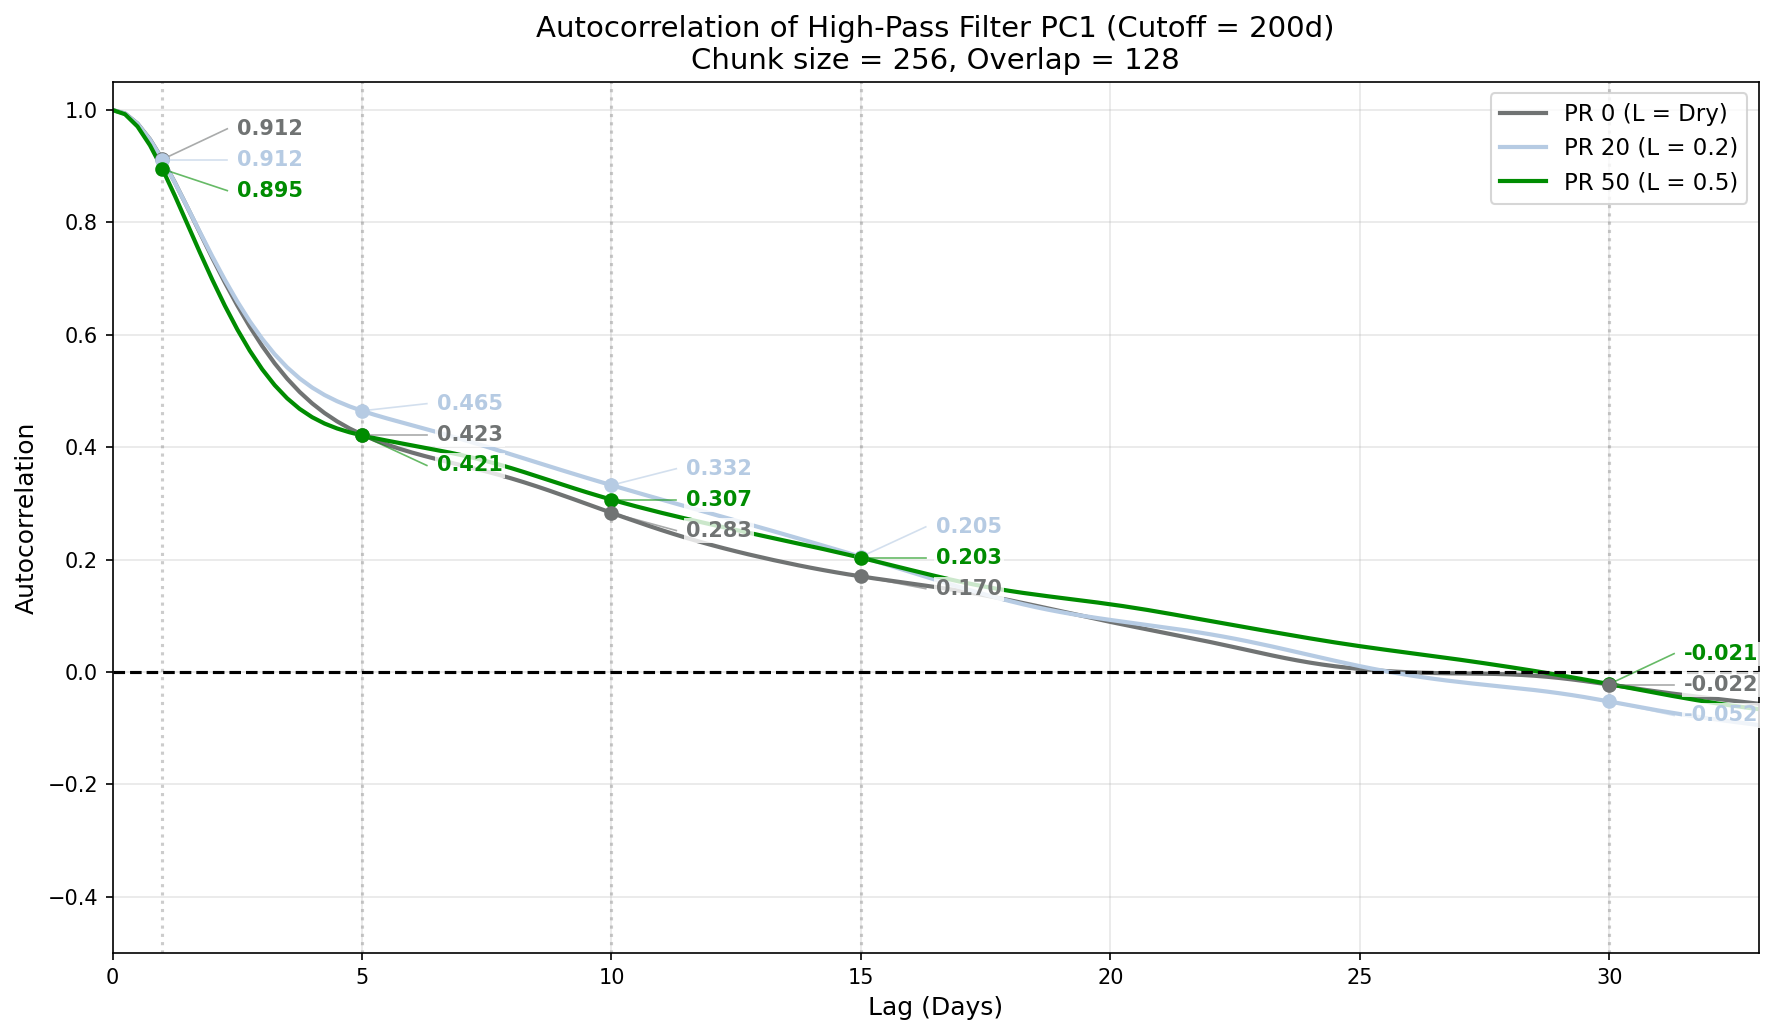

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 將 X 軸轉換為「天數 (Days)」
lags_steps = np.arange(max_safe_lags)
lags_days = lags_steps / steps_per_day

# 使用你之前定義的專業色系
custom_colors = np.array([[112, 115, 115], [182, 203, 227], [0, 140, 1]]) / 255.0

plt.figure(figsize=(12, 7), dpi=150)

# 2. 畫出原本的三條折線，注意 x 軸改用 lags_days
plt.plot(lags_days, auto_z_avg_0_filter, color=custom_colors[0], label="PR 0 (L = Dry)", linewidth=2)
plt.plot(lags_days, auto_z_avg_20_filter, color=custom_colors[1], label="PR 20 (L = 0.2)", linewidth=2)
plt.plot(lags_days, auto_z_avg_50_filter, color=custom_colors[2], label="PR 50 (L = 0.5)", linewidth=2)

# 3. 定義我們想要標示的特定天數
target_days = [1, 5, 10, 15, 30]

# 將資料打包，方便跑迴圈標示
datasets_to_mark = [
    (auto_z_avg_0_filter, custom_colors[0]),
    (auto_z_avg_20_filter, custom_colors[1]),
    (auto_z_avg_50_filter, custom_colors[2])
]

# 4. 在特定天數畫上圓點並標示精確數值
for day in target_days:
    # 換算出對應的 6-hourly index
    idx = int(day * steps_per_day) 
    
    # 畫一條淡淡的垂直虛線，引導視覺
    plt.axvline(x=day, color='gray', linestyle=':', alpha=0.4)
    
    # --- 步驟 A：蒐集當天三組資料的數值與顏色 ---
    day_points = []
    for data_array, color in datasets_to_mark:
        val = data_array[idx]
        day_points.append({'val': val, 'color': color})
        
    # --- 步驟 B：數值由大到小排序 (Top, Middle, Bottom) ---
    day_points.sort(key=lambda x: x['val'], reverse=True)
    
    # --- 步驟 C：計算防重疊的 Y 座標 ---
    y_texts = [pt['val'] for pt in day_points]
    min_gap = 0.055 # 設定文字的最小垂直安全間距 (可依視覺需求微調)
    
    # 如果最高的值離中間太近，強制往上推
    y_texts[0] = max(y_texts[0], y_texts[1] + min_gap)
    # 如果最低的值離中間太近，強制往下壓
    y_texts[2] = min(y_texts[2], y_texts[1] - min_gap)
    
    # --- 步驟 D：畫點、引導線與標示文字 ---
    for i, pt in enumerate(day_points):
        val = pt['val']
        color = pt['color']
        y_text = y_texts[i]
        
        # 文字統一往右退 1.5 天的距離，留出空間給引導線
        x_text = day + 1.5 
        
        # 1. 畫實際位置的圓點
        plt.plot(day, val, marker='o', markersize=6, color=color)
        
        # 2. 畫極細的引導線 (將真實圓點與文字的 Y 座標連起來)
        # 這樣就算文字被上下推開，讀者也絕對不會看錯對應的點
        plt.plot([day, x_text - 0.2], [val, y_text], color=color, linestyle='-', linewidth=0.8, alpha=0.6)
        
        # 3. 標示文字 (印在調整過防重疊的 y_text 位置)
        plt.text(x_text, y_text, f'{val:.3f}', color=color, fontsize=10, 
                 fontweight='bold', va='center',
                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

# 5. 圖表美化與格式設定
plt.axhline(y=0, color="Black", linestyle='--')

# 將 x 軸拉長一點點到 32，這樣 30 天的文字標籤才不會被圖表邊緣切掉
plt.xlim([0, 33]) 
plt.ylim([-0.5, 1.05])

plt.xlabel('Lag (Days)', fontsize=12)
plt.ylabel('Autocorrelation', fontsize=12)
plt.title('Autocorrelation of High-Pass Filter PC1 (Cutoff = 200d)\nChunk size = 256, Overlap = 128', fontsize=14)

plt.legend(loc="upper right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()